  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=minisom-2.3.6-py3-none-any.whl size=13171 sha256=518edd049024f7accde597b43319421b00450773d05b0da68ec43a34f07302d9
  Stored in directory: /root/.cache/pip/wheels/dc/11/f9/32be492f07fa741d7dcff82007abc966a324da6ab9ceb198e3
Successfully built minisom
Dataset Shape: (150, 4)

SOM training completed.


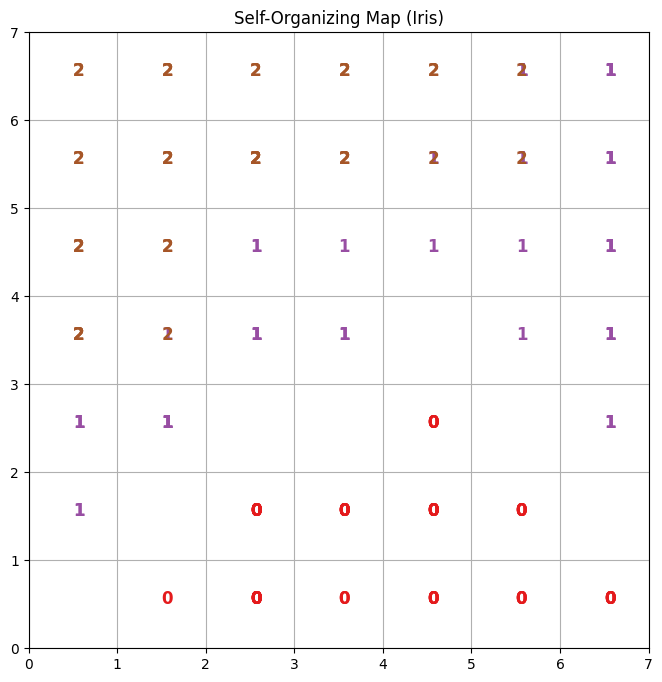

In [1]:
#Program-5
!pip install minisom scikit-learn matplotlib

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

iris=load_iris(as_frame=True)
X=iris.data.values
y=iris.target

print("Dataset Shape:",X.shape)

scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)

som_size=7
som=MiniSom(
    x=som_size,
    y=som_size,
    input_len=X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)
som.random_weights_init(X_scaled)
som.train_random(X_scaled,num_iteration=1000)

print("\nSOM training completed.")

plt.figure(figsize=(8,8))

for i,x in enumerate(X_scaled):
  w=som.winner(x)
  plt.text(
      w[0]+0.5,
      w[1]+0.5,
      str(y[i]),
      color=plt.cm.Set1(y[i]/3.),
      fontdict={'weight':'bold','size':12}
  )

plt.title("Self-Organizing Map (Iris)")
plt.xlim([0,som_size])
plt.ylim([0,som_size])
plt.grid(True)
plt.show()